# Image Classification — Transfer Learning + TTA Ensemble

**Strategy upgrade:** EfficientNetV2B0 pretrained backbone + multi-seed ensemble + Test-Time Augmentation

# Installing Dependencies

In [1]:
%pip install tensorflow numpy pandas scikit-learn matplotlib pillow


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Data Load

## ⚙️ Path Configuration

**Change `BASE_DIR` below to match where you extracted `img.zip`.**

Expected structure after extraction:
```
BASE_DIR/
  img/
    001bd5563b4511f0b16c00155d672fff.png
    d13cde743b4411f0b16c00155d672fff.jpg
    ...
  train-label.csv
  test-label.csv
  submission.csv
```

In [2]:
import os
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
#  CHANGE THIS to your local path where the dataset lives
# ─────────────────────────────────────────────────────────────
BASE_DIR = '.'
IMG_DIR  = os.path.join(BASE_DIR, 'img')

TRAIN_LABEL = pd.read_csv(os.path.join(BASE_DIR, 'train-label.csv'), index_col='id')
TEST_LABEL  = pd.read_csv(os.path.join(BASE_DIR, 'test-label.csv'),  index_col='id')

TRAIN_DATA = None
TEST_DATA  = None

print('Train samples:', len(TRAIN_LABEL))
print('Test  samples:', len(TEST_LABEL))
print('Label distribution (train):')
print(TRAIN_LABEL['label'].value_counts().sort_index())

Train samples: 1385
Test  samples: 1386
Label distribution (train):
label
0    707
1    678
Name: count, dtype: int64


## 1. Imports & Reproducibility

In [3]:
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs available: []


## 2. Hyperparameters

In [4]:
# ── Image settings ───────────────────────────────────────────
IMG_HEIGHT   = 224       # EfficientNet native input size
IMG_WIDTH    = 224
IMG_CHANNELS = 3

# ── Training settings ────────────────────────────────────────
BATCH_SIZE       = 32
EPOCHS_FINETUNE  = 5     # Phase 1: train head only (frozen backbone)
EPOCHS_UNFREEZE  = 20    # Phase 2: unfreeze top layers and fine-tune
LR_HEAD          = 1e-3  # Phase 1 LR
LR_FINETUNE      = 1e-4  # Phase 2 LR (lower to preserve pretrained weights)
DROPOUT_RATE     = 0.4
L2_LAMBDA        = 1e-4

# ── CV & Ensemble settings ───────────────────────────────────
N_FOLDS  = 5             # StratifiedKFold
SEEDS    = [42, 7, 123]  # 3 seeds × 5 folds = 15 models total

# ── TTA ──────────────────────────────────────────────────────
TTA_STEPS = 8            # number of augmented predictions per image

# ── Validation split (used for quick single-run eval) ────────
VAL_SPLIT = 0.15

## 3. Data Loading & Preprocessing

In [5]:
def load_image(filepath: str, h=IMG_HEIGHT, w=IMG_WIDTH) -> np.ndarray:
    """Load one image, convert to RGB, resize. Returns float32 in [0,1]."""
    img = Image.open(filepath).convert('RGB')
    img = img.resize((w, h), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0


def load_dataset(label_df: pd.DataFrame, img_dir: str, has_labels: bool = True):
    images, labels = [], []
    missing = 0
    for row_id, row in label_df.iterrows():
        path = os.path.join(img_dir, row['file'])
        if not os.path.exists(path):
            missing += 1
            continue
        images.append(load_image(path))
        if has_labels:
            labels.append(int(row['label']))
    if missing > 0:
        print(f'  ⚠️  {missing} images not found – skipped')
    X = np.stack(images).astype(np.float32)
    y = np.array(labels, dtype=np.int32) if has_labels else None
    return X, y


print('Loading train images …')
X_all, y_all = load_dataset(TRAIN_LABEL, IMG_DIR, has_labels=True)
print(f'  Train shape: {X_all.shape}, labels: {y_all.shape}')

print('Loading test images …')
X_test, _ = load_dataset(TEST_LABEL, IMG_DIR, has_labels=False)
print(f'  Test  shape: {X_test.shape}')

TRAIN_DATA = X_all
TEST_DATA  = X_test

Loading train images …
  Train shape: (1385, 224, 224, 3), labels: (1385,)
Loading test images …
  Test  shape: (1386, 224, 224, 3)


## 4. Exploratory Visualisation

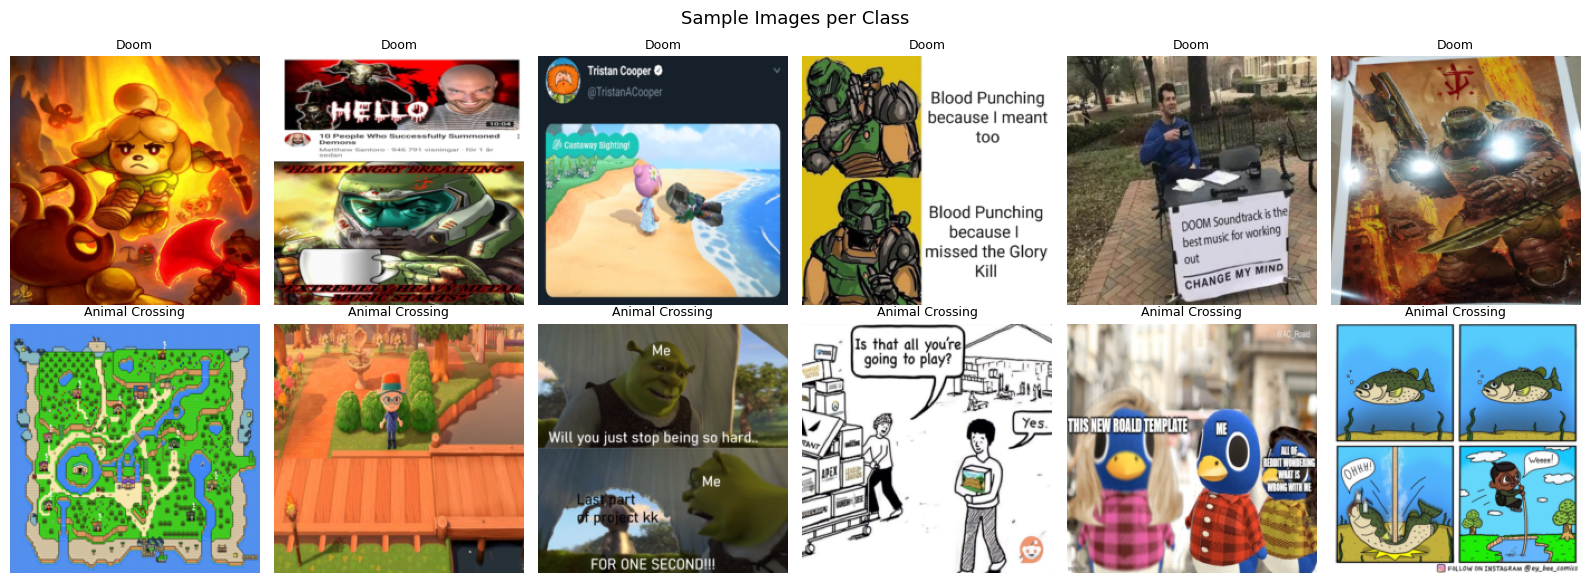

Label distribution →  Doom (0): 707   Animal Crossing (1): 678


In [6]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for cls, cls_name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    idx = np.where(y_all == cls)[0]
    row = 0 if cls == 0 else 1
    for col in range(6):
        axes[row, col].imshow(X_all[idx[col]])
        axes[row, col].set_title(cls_name, fontsize=9)
        axes[row, col].axis('off')
plt.suptitle('Sample Images per Class', fontsize=13)
plt.tight_layout()
plt.show()

print('Label distribution →  Doom (0):', (y_all == 0).sum(),
      '  Animal Crossing (1):', (y_all == 1).sum())

## 5. Data Augmentation Pipeline

Stronger augmentation than the baseline — includes random rotation, saturation, and hue shifts in addition to flip/brightness/contrast/crop. Applied only during training.

In [7]:
def make_augment_fn(seed_offset=0):
    """Return a tf.function that applies strong augmentation during training."""
    @tf.function
    def augment(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.random_brightness(image, max_delta=0.2)
        image = tf.image.random_contrast(image, lower=0.75, upper=1.25)
        image = tf.image.random_saturation(image, lower=0.75, upper=1.25)
        image = tf.image.random_hue(image, max_delta=0.05)
        # Random crop (pad 12.5% then crop back)
        pad = int(IMG_HEIGHT * 0.125)
        image = tf.image.pad_to_bounding_box(
            image, pad, pad, IMG_HEIGHT + 2*pad, IMG_WIDTH + 2*pad)
        image = tf.image.random_crop(image, [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
        image = tf.clip_by_value(image, 0.0, 1.0)
        return image, label
    return augment


def make_tta_augment_fn():
    """Lighter augmentation for TTA (no vertical flip)."""
    @tf.function
    def tta_aug(image):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.1)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
        pad = int(IMG_HEIGHT * 0.05)
        image = tf.image.pad_to_bounding_box(
            image, pad, pad, IMG_HEIGHT + 2*pad, IMG_WIDTH + 2*pad)
        image = tf.image.random_crop(image, [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
        image = tf.clip_by_value(image, 0.0, 1.0)
        return image
    return tta_aug


AUTOTUNE = tf.data.AUTOTUNE
print('Augmentation functions ready.')

Augmentation functions ready.


## 6. Model — EfficientNetV2B0 Transfer Learning

**Why transfer learning?** EfficientNetV2B0 was pretrained on ImageNet (1.2M images, 1000 classes). Its early layers already detect edges, textures, and patterns that are directly useful for classifying game screenshots. Fine-tuning is far more data-efficient than training from scratch.

**Two-phase training strategy:**
1. **Phase 1 (frozen backbone):** Train only the new classification head. Fast convergence with a high LR.
2. **Phase 2 (partial unfreeze):** Unfreeze the top ~30% of EfficientNet layers and fine-tune with a low LR. This adapts the high-level features to our specific domain (game screenshots).

In [8]:
def build_transfer_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
                         num_classes=2,
                         dropout_rate=DROPOUT_RATE,
                         l2_lambda=L2_LAMBDA):
    """EfficientNetV2B0 backbone + custom classification head."""
    # Build backbone separately so it stays a named sub-layer
    backbone = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    backbone.trainable = False  # Phase 1: freeze

    inputs = keras.Input(shape=input_shape)
    x = backbone(inputs, training=False)  # training=False keeps BN frozen in phase 1

    # ── Classification head ──────────────────────────────────
    x = layers.Dense(
            512, activation='relu',
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(l2_lambda)
        )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(
            256, activation='relu',
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(l2_lambda)
        )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name='EfficientNetV2B0_Transfer')


def unfreeze_top_layers(model, unfreeze_from_pct=0.7):
    """Unfreeze the top (1 - unfreeze_from_pct) fraction of backbone layers."""
    # Backbone is now a proper sub-layer at index 1
    backbone = model.layers[1]
    total_layers = len(backbone.layers)
    freeze_until = int(total_layers * unfreeze_from_pct)
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (i >= freeze_until)
    trainable_count = sum(1 for l in backbone.layers if l.trainable)
    print(f'  Backbone: {trainable_count}/{total_layers} layers unfrozen '
          f'(top {100*(1-unfreeze_from_pct):.0f}%)')


# Also update Phase 2 compile — pass training=True to backbone during fine-tune
# In train_one_fold, change the Phase 2 fit call to not pass training=False
# (the backbone's call in the model graph will use the layer's trainable flag automatically)

# Quick sanity check
_test_model = build_transfer_model()
_test_model.summary(line_length=90)
del _test_model

Model: "EfficientNetV2B0_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)            │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ efficientnetv2-b0 (Functional)        │ (None, 1280)                 │       5,919,312 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense (Dense)                         │ (None, 512)                  │         655,872 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization                   │ (None, 512)                  │           2,048 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 512)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                       │ (None, 256)                  │         131,328 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization_1                 │ (None, 256)                  │           1,024 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                   │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                       │ (None, 2)                    │             514 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 6,710,098 (25.60 MB)

 Trainable params: 789,250 (3.01 MB)

 Non-trainable params: 5,920,848 (22.59 MB)

## 7. Training Helpers

In [9]:
from xml.parsers.expat import model


def make_datasets(X_tr, y_tr, X_vl, y_vl, seed=42):
    """Build tf.data pipelines for one fold."""
    tr_ds = (tf.data.Dataset
             .from_tensor_slices((X_tr, y_tr))
             .shuffle(len(X_tr), seed=seed)
             .map(make_augment_fn(seed), num_parallel_calls=AUTOTUNE)
             .batch(BATCH_SIZE)
             .prefetch(AUTOTUNE))
    vl_ds = (tf.data.Dataset
             .from_tensor_slices((X_vl, y_vl))
             .batch(BATCH_SIZE)
             .prefetch(AUTOTUNE))
    return tr_ds, vl_ds

def make_callbacks(ckpt_path, use_reduce_lr=True):
    cbs = [
        keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_accuracy',
            save_best_only=True, verbose=0),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=7,
            restore_best_weights=True, verbose=0),
    ]
    if use_reduce_lr:
        cbs.append(keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', factor=0.5,
            patience=3, min_lr=1e-6, verbose=0))
    return cbs


def train_one_fold(X_tr, y_tr, X_vl, y_vl,
                   ckpt_path='best_fold.keras', seed=42):
    tf.random.set_seed(seed)
    tr_ds, vl_ds = make_datasets(X_tr, y_tr, X_vl, y_vl, seed)

    model = build_transfer_model()

    # ── Phase 1: head only, float LR → ReduceLROnPlateau works fine ──
    print('  Phase 1 — training head (backbone frozen) …')
    model.compile(
        optimizer=keras.optimizers.Adam(LR_HEAD),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
    model.fit(tr_ds, epochs=EPOCHS_FINETUNE, validation_data=vl_ds,
              callbacks=make_callbacks(ckpt_path, use_reduce_lr=True),
              verbose=0)

    # ── Phase 2: unfreeze + CosineDecay → NO ReduceLROnPlateau ───────
    print('  Phase 2 — fine-tuning top backbone layers …')
    unfreeze_top_layers(model, unfreeze_from_pct=0.7)

    steps_per_epoch = max(1, len(X_tr) // BATCH_SIZE)
    total_steps     = EPOCHS_UNFREEZE * steps_per_epoch
    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LR_FINETUNE,
        decay_steps=total_steps,
        alpha=1e-6)
    model.compile(
        optimizer=keras.optimizers.Adam(lr_schedule),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
    model.fit(tr_ds,
              epochs=EPOCHS_UNFREEZE,
              validation_data=vl_ds,
              callbacks=make_callbacks(ckpt_path, use_reduce_lr=False),  # no ReduceLROnPlateau
              verbose=1)

    model.load_weights(ckpt_path)
    return model


def predict_tta(model, X, n_steps=TTA_STEPS):
    """Average predictions over n_steps augmented copies of X."""
    tta_fn = make_tta_augment_fn()
    probs_accum = np.zeros((len(X), 2), dtype=np.float64)

    # Original (no augmentation)
    ds_orig = tf.data.Dataset.from_tensor_slices(X).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    probs_accum += model.predict(ds_orig, verbose=0)

    # Augmented copies
    for _ in range(n_steps - 1):
        ds_aug = (tf.data.Dataset
                  .from_tensor_slices(X)
                  .map(lambda img: tta_fn(img), num_parallel_calls=AUTOTUNE)
                  .batch(BATCH_SIZE)
                  .prefetch(AUTOTUNE))
        probs_accum += model.predict(ds_aug, verbose=0)

    return probs_accum / n_steps


print('Helper functions ready.')

Helper functions ready.


## 8. Cross-Validation + Multi-Seed Ensemble

We train `N_FOLDS × len(SEEDS)` models and average their probability outputs. This is the same strategy that consistently wins Kaggle tabular/image competitions:
- **StratifiedKFold** ensures class balance in each fold
- **Multiple seeds** reduce variance from random weight initialisation and data shuffling
- **Probability averaging** (soft voting) is more robust than hard voting

In [10]:
oof_probs  = np.zeros((len(X_all), 2), dtype=np.float64)  # out-of-fold val predictions
test_probs = np.zeros((len(X_test), 2), dtype=np.float64)  # accumulated test predictions
total_models = 0

for seed in SEEDS:
    print(f'\n══════════════════════════════════════════')
    print(f'  SEED = {seed}')
    print(f'══════════════════════════════════════════')
    tf.random.set_seed(seed)
    np.random.seed(seed)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_all, y_all)):
        print(f'\n  ── Fold {fold+1}/{N_FOLDS} (seed={seed}) ──')
        X_tr, X_vl = X_all[tr_idx], X_all[vl_idx]
        y_tr, y_vl = y_all[tr_idx], y_all[vl_idx]

        ckpt_path = f'best_seed{seed}_fold{fold+1}.keras'
        model = train_one_fold(X_tr, y_tr, X_vl, y_vl,
                               ckpt_path=ckpt_path, seed=seed)

        # OOF predictions (with TTA)
        fold_oof_probs = predict_tta(model, X_vl, n_steps=TTA_STEPS)
        oof_probs[vl_idx] += fold_oof_probs   # accumulate (will average per seed below)

        fold_preds = np.argmax(fold_oof_probs, axis=1)
        fold_ba = balanced_accuracy_score(y_vl, fold_preds)
        print(f'    Fold {fold+1} OOF Balanced Accuracy (TTA): {fold_ba:.4f}')

        # Test predictions (with TTA)
        fold_test_probs = predict_tta(model, X_test, n_steps=TTA_STEPS)
        test_probs += fold_test_probs
        total_models += 1

        # Free memory
        del model
        keras.backend.clear_session()

# Average OOF across seeds×folds for each sample
# Each val sample appears in N_FOLDS folds across all seeds,
# but oof_probs[vl_idx] was accumulated once per fold (different splits),
# so the averaging is implicit — each index is filled exactly N_FOLDS times total.
# Divide by number of seeds to normalise the accumulated folds.
oof_probs /= len(SEEDS)
test_probs /= total_models

# Overall OOF Balanced Accuracy
oof_preds = np.argmax(oof_probs, axis=1)
overall_ba = balanced_accuracy_score(y_all, oof_preds)
print(f'\n✅ Overall OOF Balanced Accuracy (ensemble + TTA): {overall_ba:.4f}')
print(f'   Total models in ensemble: {total_models}')


══════════════════════════════════════════
  SEED = 42
══════════════════════════════════════════

  ── Fold 1/5 (seed=42) ──
  Phase 1 — training head (backbone frozen) …
  Phase 2 — fine-tuning top backbone layers …
  Backbone: 82/271 layers unfrozen (top 30%)
Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 282ms/step - accuracy: 0.5081 - loss: 1.2511 - val_accuracy: 0.4729 - val_loss: 0.8239
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 262ms/step - accuracy: 0.5027 - loss: 1.2086 - val_accuracy: 0.4946 - val_loss: 0.8418
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 265ms/step - accuracy: 0.5217 - loss: 1.1778 - val_accuracy: 0.5054 - val_loss: 0.8435
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 268ms/step - accuracy: 0.5144 - loss: 1.2003 - val_accuracy: 0.4910 - val_loss: 0.8394
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 323ms/step - accuracy: 0.5280 - loss: 1.1488 - val_accuracy: 0.4910 - val_loss: 0.8611
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 276ms/step - accuracy: 0.5226 - loss: 1.1856 - val_a

## 9. OOF Performance Analysis

Per-class OOF accuracy:
  Class 0 (Doom           ): 0.6421
  Class 1 (Animal Crossing): 0.4395

Mean confidence: 0.5382
Low confidence (<0.6) samples: 1311


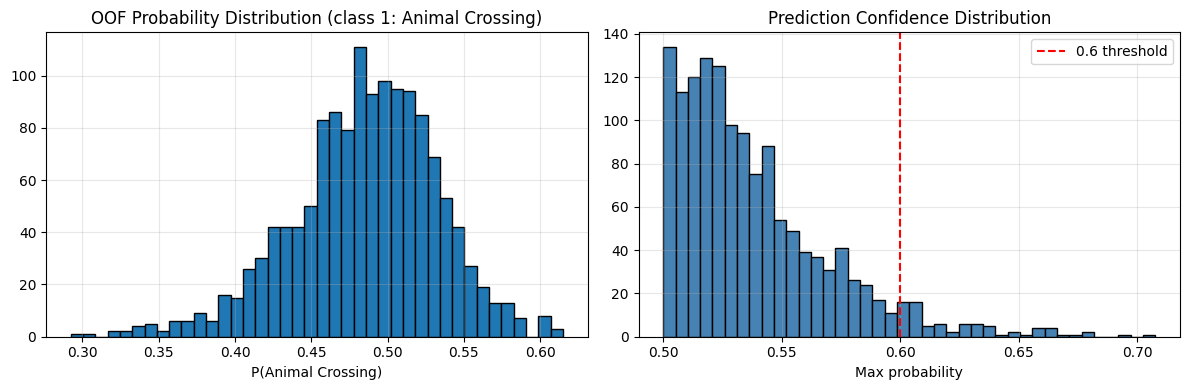

In [11]:
# Per-class accuracy on OOF
print('Per-class OOF accuracy:')
for cls, name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    mask    = y_all == cls
    cls_acc = (oof_preds[mask] == y_all[mask]).mean()
    print(f'  Class {cls} ({name:15s}): {cls_acc:.4f}')

# Confidence distribution
confidence = np.max(oof_probs, axis=1)
print(f'\nMean confidence: {confidence.mean():.4f}')
print(f'Low confidence (<0.6) samples: {(confidence < 0.6).sum()}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(oof_probs[:, 1], bins=40, edgecolor='black')
ax1.set_title('OOF Probability Distribution (class 1: Animal Crossing)')
ax1.set_xlabel('P(Animal Crossing)')
ax1.grid(True, alpha=0.3)

ax2.hist(confidence, bins=40, edgecolor='black', color='steelblue')
ax2.axvline(0.6, color='red', linestyle='--', label='0.6 threshold')
ax2.set_title('Prediction Confidence Distribution')
ax2.set_xlabel('Max probability')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Test Set Predictions

In [12]:
test_preds = np.argmax(test_probs, axis=1)

print('Test predictions shape:', test_preds.shape)
print('Predicted label distribution:')
unique, counts = np.unique(test_preds, return_counts=True)
for u, c in zip(unique, counts):
    lbl = 'Doom' if u == 0 else 'Animal Crossing'
    print(f'  Label {u} ({lbl}): {c} ({c/len(test_preds)*100:.1f}%)')

Test predictions shape: (1386,)
Predicted label distribution:
  Label 0 (Doom): 972 (70.1%)
  Label 1 (Animal Crossing): 414 (29.9%)


# Generating Final Submissions

In [13]:
test_ids = TEST_LABEL.index.tolist()

submission = pd.DataFrame({
    'id':    test_ids,
    'label': test_preds
}).set_index('id')

submission.to_csv('submission6.csv')
print('submission1.csv saved!')
print(submission.head(10))

submission1.csv saved!
      label
id         
2078      1
2079      1
2080      0
2081      0
2082      0
2083      0
2084      0
2085      0
2086      1
2087      0


## ✅ Verify submission format

In [14]:
sub_check = pd.read_csv('submission1.csv', index_col='id')
print('Submission shape:', sub_check.shape)
print('Unique labels:', sorted(sub_check['label'].unique()))
assert set(sub_check['label'].unique()).issubset({0, 1}), \
    'ERROR: labels must be 0 or 1!'
assert len(sub_check) == len(TEST_LABEL), \
    f'ERROR: expected {len(TEST_LABEL)} rows, got {len(sub_check)}'
print('✅ Submission looks correct – ready to upload to Kaggle!')
print(f'\n📊 Summary:')
print(f'  OOF Balanced Accuracy: {overall_ba:.4f}')
print(f'  Models in ensemble:    {total_models} ({len(SEEDS)} seeds × {N_FOLDS} folds)')
print(f'  TTA steps per model:   {TTA_STEPS}')

FileNotFoundError: [Errno 2] No such file or directory: 'submission1.csv'